# Exploratory Data Analysis: UV Radiation

Comparison of UV characteristics between Algeria (high-UV region) and Sweden (Nordic region).

**Data Sources:**
- Algeria: `data/algeria/Algeria.csv`
- Sweden: `data/countries/uv/Sweden.csv`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Loading

In [ ]:
df_algeria = pd.read_csv('data/algeria/Algeria.csv')
df_sweden = pd.read_csv('data/countries/uv/Sweden.csv')

df_algeria['Date'] = pd.to_datetime(df_algeria['Date'])
df_sweden['Date'] = pd.to_datetime(df_sweden['Date'])

df_algeria.set_index('Date', inplace=True)
df_sweden.set_index('Date', inplace=True)

df_algeria['Country'] = 'Algeria'
df_sweden['Country'] = 'Sweden'

print("Algeria:", df_algeria.index.min(), "to", df_algeria.index.max())
print("Sweden:", df_sweden.index.min(), "to", df_sweden.index.max())
display(df_algeria.head())

Algeria Data Range: 1981-01-01 00:00:00 to 2025-11-01 00:00:00
Sweden Data Range: 1981-01-01 00:00:00 to 2025-11-01 00:00:00


,T2M,T2MDEW,T2MWET,TS,T2M_RANGE,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,...,WD50M,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,ALLSKY_KT,ALLSKY_SFC_LW_DWN,ALLSKY_SFC_UV_INDEX,ALLSKY_SFC_UVA,ALLSKY_SFC_UVB,TO3,Country
Date,,,,,,,,,,,,,,,,,,,,,
1981-01-01,12.61,8.93,10.77,13.91,2.77,14.09,11.32,78.21,0.01,4.82,...,291.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,330.99,Algeria
1981-01-02,13.00,8.09,10.54,13.74,1.26,13.53,12.27,72.35,0.17,2.83,...,316.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,293.24,Algeria
1981-01-03,12.63,9.36,11.00,13.47,2.31,13.92,11.61,80.56,0.53,3.71,...,261.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,285.60,Algeria
1981-01-04,13.56,10.78,12.17,13.78,2.74,14.80,12.06,83.31,0.22,6.44,...,264.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,296.27,Algeria
1981-01-05,12.99,10.01,11.50,13.62,2.08,14.05,11.97,82.49,0.78,4.98,...,298.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,294.81,Algeria


## 2. Algeria UV Distribution

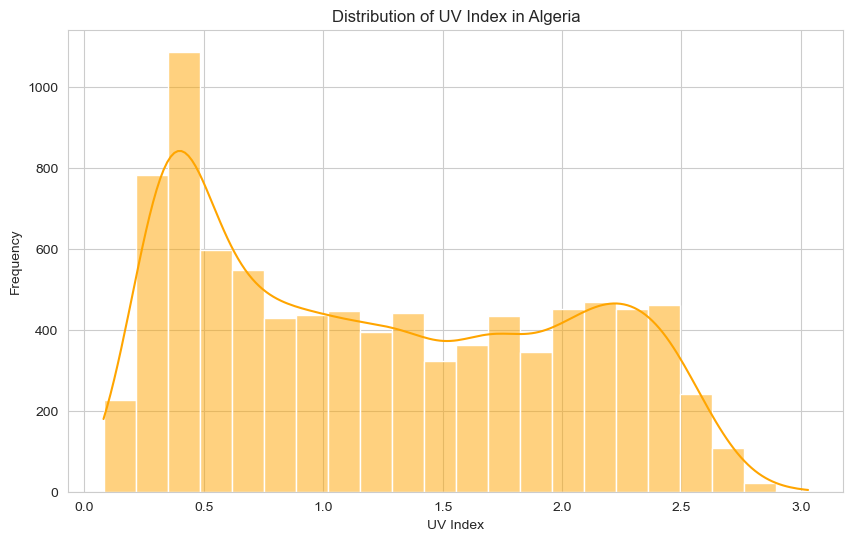

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_algeria['ALLSKY_SFC_UV_INDEX'], kde=True, color='orange')
plt.title('UV Index Distribution - Algeria')
plt.xlabel('UV Index')
plt.ylabel('Frequency')
plt.show()

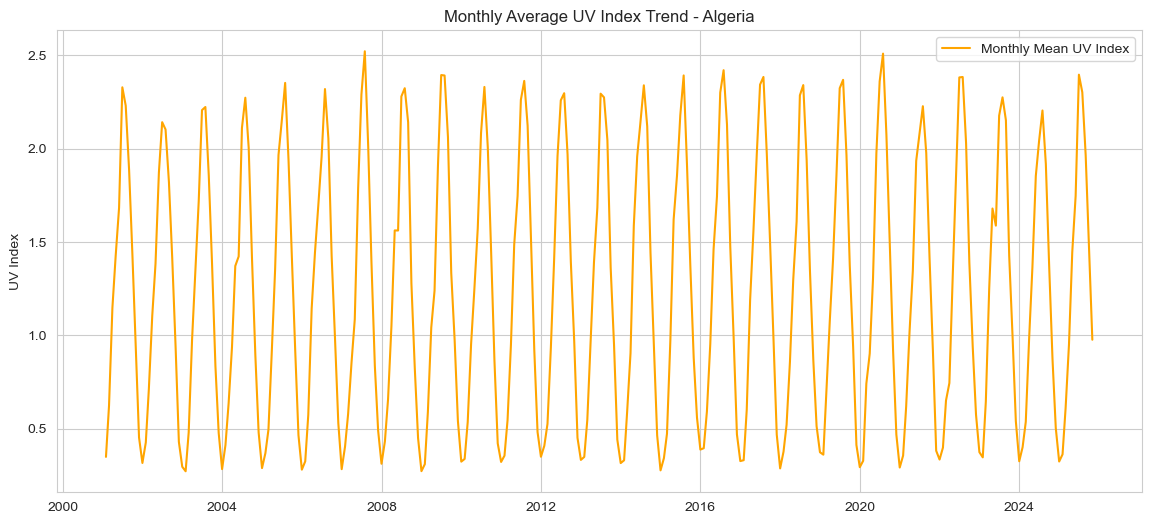

In [ ]:
algeria_monthly = df_algeria['ALLSKY_SFC_UV_INDEX'].resample('ME').mean()

plt.figure(figsize=(14, 6))
plt.plot(algeria_monthly, color='orange')
plt.title('Monthly Mean UV Index - Algeria')
plt.ylabel('UV Index')
plt.show()

## 3. Sweden UV Distribution

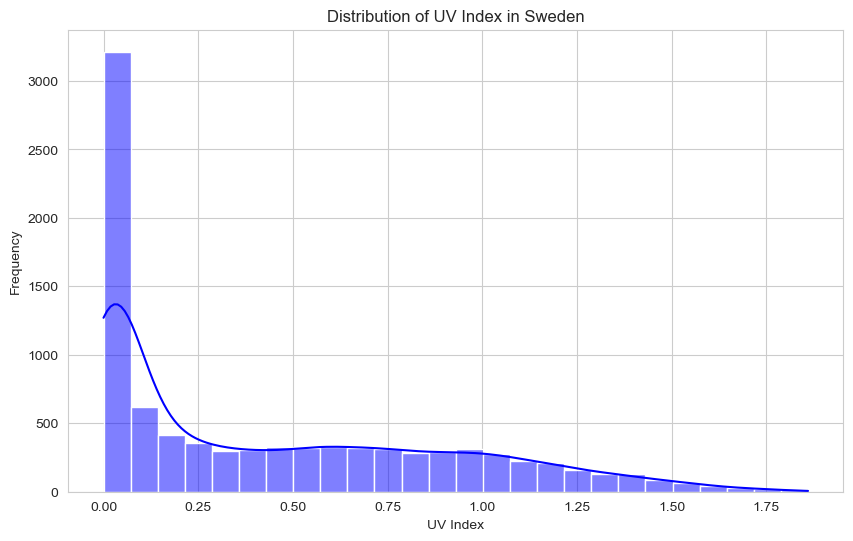

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_sweden['ALLSKY_SFC_UV_INDEX'], kde=True, color='blue')
plt.title('UV Index Distribution - Sweden')
plt.xlabel('UV Index')
plt.ylabel('Frequency')
plt.show()

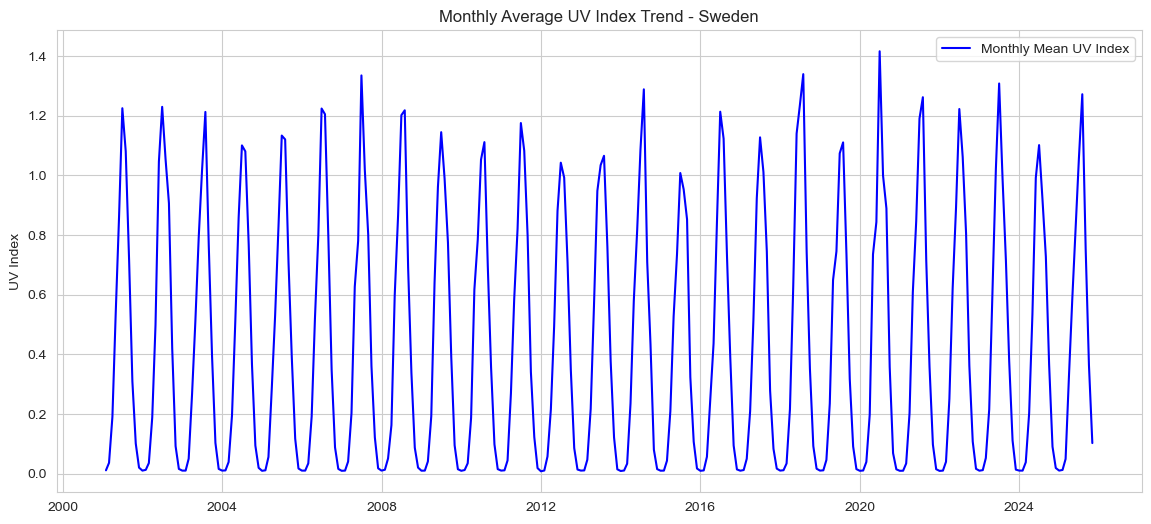

In [ ]:
sweden_monthly = df_sweden['ALLSKY_SFC_UV_INDEX'].resample('ME').mean()

plt.figure(figsize=(14, 6))
plt.plot(sweden_monthly, color='blue')
plt.title('Monthly Mean UV Index - Sweden')
plt.ylabel('UV Index')
plt.show()

## 4. Comparative Analysis

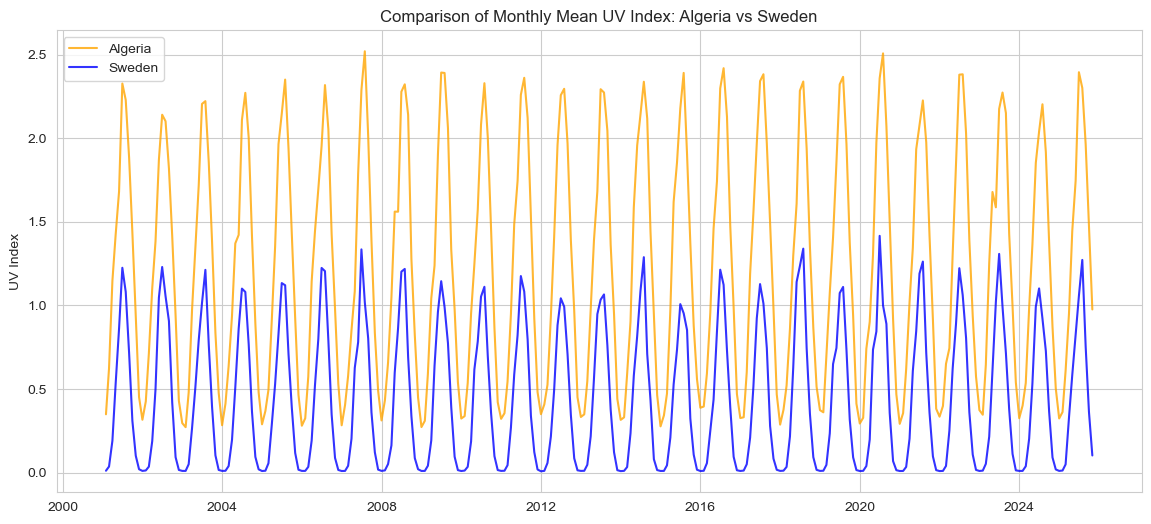

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(algeria_monthly, color='orange', label='Algeria', alpha=0.8)
plt.plot(sweden_monthly, color='blue', label='Sweden', alpha=0.8)
plt.title('Monthly Mean UV Index Comparison')
plt.ylabel('UV Index')
plt.legend()
plt.show()

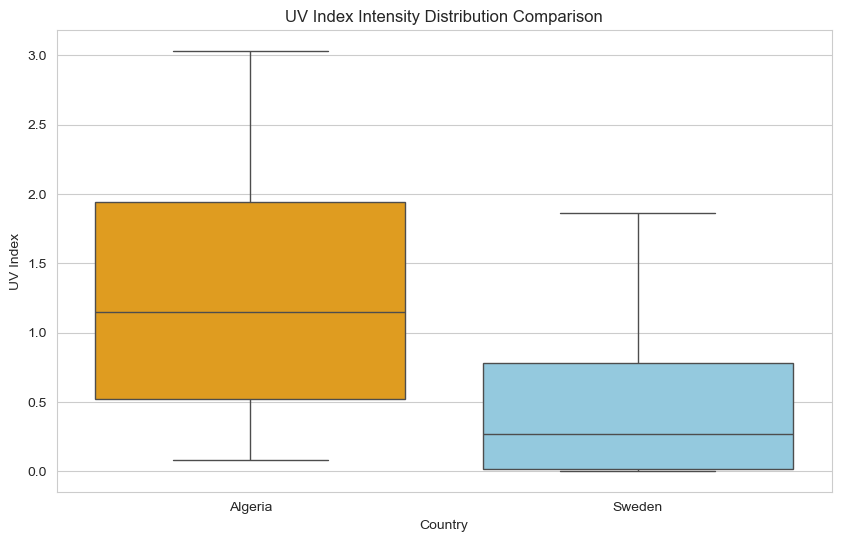

In [ ]:
df_combined = pd.concat([df_algeria[['ALLSKY_SFC_UV_INDEX', 'Country']].reset_index(), 
                         df_sweden[['ALLSKY_SFC_UV_INDEX', 'Country']].reset_index()], ignore_index=True)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Country', y='ALLSKY_SFC_UV_INDEX', data=df_combined, palette=['orange', 'skyblue'], hue='Country', legend=False)
plt.title('UV Index Distribution Comparison')
plt.ylabel('UV Index')
plt.show()

### Seasonal Profile

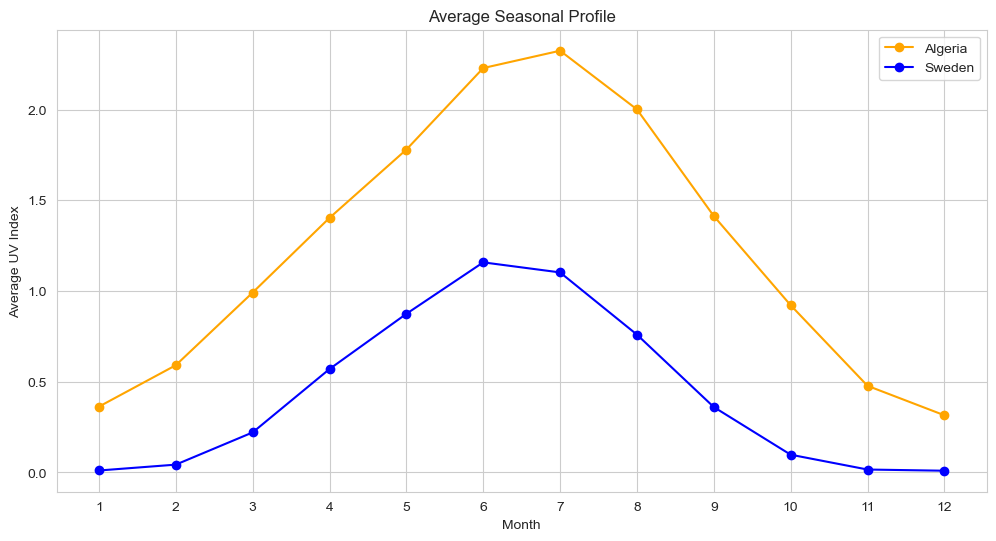

In [ ]:
df_algeria['Month'] = df_algeria.index.month
df_sweden['Month'] = df_sweden.index.month

algeria_seasonality = df_algeria.groupby('Month')['ALLSKY_SFC_UV_INDEX'].mean()
sweden_seasonality = df_sweden.groupby('Month')['ALLSKY_SFC_UV_INDEX'].mean()

plt.figure(figsize=(12, 6))
plt.plot(algeria_seasonality.index, algeria_seasonality.values, marker='o', color='orange', label='Algeria')
plt.plot(sweden_seasonality.index, sweden_seasonality.values, marker='o', color='blue', label='Sweden')
plt.title('Average Seasonal Profile')
plt.xlabel('Month')
plt.ylabel('Average UV Index')
plt.xticks(range(1, 13))
plt.legend()
plt.show()

### Correlation Matrix (Algeria)

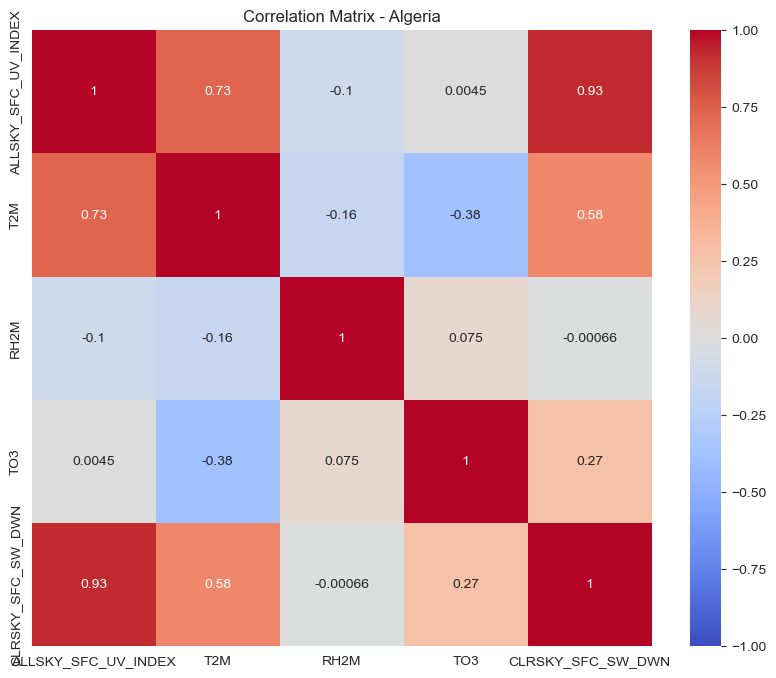

In [ ]:
cols_to_corr = ['ALLSKY_SFC_UV_INDEX', 'T2M', 'RH2M', 'TO3', 'CLRSKY_SFC_SW_DWN']
cols_to_corr = [c for c in cols_to_corr if c in df_algeria.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(df_algeria[cols_to_corr].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix - Algeria')
plt.show()

## Summary

### Findings
- Algeria exhibits ~3x higher UV levels than Sweden year-round
- Sweden shows extreme seasonality with near-zero UV in winter
- Algeria maintains substantial UV even during winter months

### Data Note
Maximum UV values (~3.0) indicate daily means rather than daily peaks. The WHO UV Index scale (0-11+) uses peak values, so a scaling factor (~3.0x) is required for risk classification.